In [1]:
# %%file SolveLoads.py
import sys
sys.path.append('../')

import numpy as np
from Equilibrium import *
from constants import *

def SolveACLoads(cg, acf, acb):
    Weight = PointLoad([0, - mTO * 9.81, 0], [cg, 0, 0])
    LFront = PointLoad([0, 1, 0], [acf, 0, 0])
    LBack = PointLoad([0, 1, 0], [acb, 0, 0])
    motion = EquilibriumEquation(kloads = [Weight], ukloads=[LFront, LBack])
    motion.SetupEquation()
    return list(motion.SolveEquation())

def SolveWingLoads(MAC, b, Lwing, Dwing, mWing, TpE, nE):
    pos = np.linspace(0, b / 2)
    WingWeight = RunningLoad([[0]*len(pos), [- mWing * 9.81 / b]*len(pos)], pos, axis=2)
    Lift = RunningLoad([[0]*len(pos), [Lwing * 2 / b] * len(pos)], pos, axis=2)
    Drag = RunningLoad([[Dwing * 2 / b] * len(pos), [0]*len(pos)], pos, axis=2)
    Thrust = [PointLoad([-TpE, 0, 0], [0, 0, i]) for i in np.linspace(0, b, nE)]
    MomentAC = Moment(value=[0, 0, 30])

    Fixedx = PointLoad([1, 0, 0], [0.5 * MAC, 0, 0])
    Fixedy = PointLoad([0, 1, 0], [0.5 * MAC, 0, 0])
    Fixedz = PointLoad([0, 0, 1], [0.5 * MAC, 0, 0])

    FixedMomentx, FixedMomenty, FixedMomentz = Moment([1, 0, 0]), Moment([0, 1, 0]), Moment([0, 0, 1])
    wingequation = EquilibriumEquation(kloads=[WingWeight, Lift, Drag, MomentAC] + Thrust,
                                       ukloads=[Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz])
    wingequation.SetupEquation()
    return wingequation

In [2]:
print(ACLoads := SolveACLoads(1.95, 0.5, 3.5))
wingequation = SolveWingLoads(0.2, 11.2, ACLoads[0], 800, mTO / 8, 100, 3)
print(WingLoads := list(wingequation.SolveEquation()))

[9787.273500000003, 9155.8365]
[-500.0, -8603.329125000004, 0.0, 24089.321550000008, -560.0, 830.3329125000005]


In [3]:
# uk: [ Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz ]
# C1: [ -700.      -7419.38475     0.      20774.2773    -1960.       0. ]
# C2: [ -600.      -7103.66625     0.      19890.2655    -1680.       0. ]
# C3: [ -800.    -14883.87214286   0.     41674.842      -2240.       0. ]

In [4]:
# %%file Analysis.py
from MathFunctions.Trigonometry import pi
from MathFunctions.Mechanics import StepFunction
import pandas as pd

class WingBox:
    def __init__(self, thickness, base, height):
        self.b, self.h, self.t = base, height, thickness
    
    Area = lambda self: self.b * self.h - (self.b - 2 * self.t) * (self.h - 2 * self.t)

    Ixx = lambda self: (self.t * self.h ** 3 + self.b * self.t ** 3) / 6 + (self.t * self.b * self.h ** 2) / 2
    
    Iyy = lambda self: (self.t ** 3 * self.h + self.b ** 3 * self.t) / 6 + (self.t * self.h * self.b ** 2) / 2
    
    Vc = Ixy = lambda self: 0
    
    def Vshear(self, Vy, x, y):
        Ixx = self.Ixx()
        inrge = lambda l1, u1, l2, u2: l1 <= x <= u1 and l2 <= y <= u2
        vit = - Vy * self.t / Ixx
        if inrge(0, self.b/2, -self.h/2, -self.h/2 + self.t):
            return vit * (-self.h * x / 2)
        elif inrge(self.b/2-self.t, self.b/2, -self.h/2, self.h/2):
            s = self.h/2 + y
            return vit * (0.5 * s * s - self.h * s / 2) + self.Vshear(Vy, self.b/2, -self.h/2)
        elif inrge(-self.b/2, self.b/2, self.h/2-self.t, self.h/2):
            s = self.b/2 - x
            return vit * (self.h*s/2) + self.Vshear(Vy, self.b/2, self.h/2)
        elif inrge(-self.b/2, -self.b/2+self.t, -self.h/2, self.h/2):
            s = self.h/2 - y
            return vit * (-0.5 * s * s + self.h * s / 2) + self.Vshear(Vy, -self.b/2, self.h/2)
        elif inrge(-self.b/2, 0, -self.h/2, -self.h/2+self.t):
            return vit * (-self.h * (x + self.b/2) / 2) + self.Vshear(Vy, -self.b/2, -self.h/2)
        else:
            raise ValueError(f"Invalid Coordinates Supplied: {(x, y) = }")

    def Hshear(self, Vx, x, y):
        Iyy = self.Iyy()
        inrge = lambda l1, u1, l2, u2: l1 <= x <= u1 and l2 <= y <= u2
        vit = - Vx * self.t / Iyy
        if inrge(-self.b/2, -self.b/2+self.t, -self.h/2, 0):
            return vit * (self.b * y / 2)
        elif inrge(-self.b/2, self.b/2, -self.h/2, -self.h/2+self.t):
            s = x + self.b/2
            return vit * (0.5 * s * s - self.b * s / 2) + self.Hshear(Vx, -self.b/2, -self.h/2)
        elif inrge(self.b/2 -self.t, self.b, -self.h/2, self.h/2):
            return vit * (self.b * (y + self.h/2) / 2) + self.Hshear(Vx, self.b/2, -self.h/2)
        elif inrge(-self.b/2, self.b/2, self.h/2-self.t, self.h/2):
            s = -x + self.b/2
            return vit * (-0.5 * s * s + self.b * s / 2) + self.Hshear(Vx, self.b/2, self.h/2)
        elif inrge(-self.b/2, -self.b/2+self.t, 0, self.h/2):
            return vit * (-self.b * (self.h/2-y) / 2) + self.Hshear(Vx, -self.b/2, self.h/2)
        else:
            raise ValueError(f"Invalid Coordinates Supplied: {(x, y) = }")
    
    @staticmethod
    def buckling(shorterSideOfSkin, skinThickness, E, v=0.33):
        C = 5.41 # SSCS Support
        b = shorterSideOfSkin
        t = skinThickness
        return C * pi * pi * E * (t / b) ** 2 / (12 * (1 - v * v))
    
    q = lambda self, x, y, Vx=0, Vy=0, T=0: self.Vshear(Vy, x, y) + self.Hshear(Vx, x, y) + T / (2 * self.Area())
    tau = lambda self, x, y, Vx=0, Vy=0, T=0: self.q(x, y, Vx, Vy, T) / self.t
    o = lambda self, x, y, Mx=0, My=0: My * x / self.Iyy() + Mx * y / self.Ixx()

class WingStructure:
    def __init__(self, wingequation):
        WingLoads = wingequation.SolveEquation()
        self.RFx, self.RFy, self.RFz = WingLoads[:3]
        self.RMx, self.RMy, self.RMz = WingLoads[3:] # WingWeight, Lift, Drag, MomentAC, Thrust
        self.W, self.L, self.D, self.Mac, *self.T = wingequation.k

        self.N = self.Vx = self.Vy = self.Mz = self.Mx = self.My = None
        self.v = self.w = self.phi = None

    def compute_loading(self):
        self.N = StepFunction([[self.RFz, 0, 0]])
        qxzcoef = list(np.polyfit(self.W.p, self.W.v[0] + self.D.v[0] + self.L.v[0], 4))
        qyzcoef = list(np.polyfit(self.W.p, self.W.v[1] + self.D.v[1] + self.L.v[1], 4))
        qxz = StepFunction([[xi, 0, i] for i, xi in enumerate(qxzcoef)])
        qyz = StepFunction([[yi, 0, i] for i, yi in enumerate(qyzcoef)])
        self.Vx = StepFunction([[self.RFx, 0, 0]] + [[T.f[0], T.p[2], 0] for T in self.T]) + qxz.integral()
        self.Vy = StepFunction([[self.RFy, 0, 0]] + [[T.f[1], T.p[2], 0] for T in self.T]) + qyz.integral()
        self.Mz = self.L.pa[0] * qyz.integral() - self.L.pa[1] * qxz.integral() # Fix
        self.My, self.Mx = self.Vx.integral(), self.Vy.integral()
        return [self.N, self.Vx, self.Vy, self.Mx, self.My, self.Mz]

    def compute_deflections(self, E, Ixx, Iyy=None):
        Iyy = Ixx if Iyy is None else Iyy
        self.v = -self.My.integral().integral() / (E * Ixx)
        self.w = self.Mx.integral().integral() / (E * Iyy)
        return self.v, self.w

    def create_nvm(self, b):
        x = np.linspace(0, b/2, 100)
        df = pd.DataFrame({'z': x} | {ln: [lv(xi) for xi in x] for ln, lv in \
                            zip(('v', 'w', 'Mx', 'My', 'Mz', 'N', 'Vx', 'Vy'), 
                                (self.v, self.w, self.Mx, self.My, self.Mz, self.N, self.Vx, self.Vy))}) \
                                    .set_index('z')
        for col in df.columns:
            df.plot(y=col)
    

In [5]:
wingbox = WingBox(5e-3, 2, 0.5)
wingbox.Hshear(100, 0, wingbox.h/2)

-32.14282844390318

In [8]:
wing = WingStructure(wingequation)
wing.compute_loading()
wing.compute_deflections(60e9, 1.005e-4, 1.005e-2)[0]

+2e-05[z]^3 +0.0[z-5.6]^3 +0.0[z-11.2]^3 +0.0[z]^4 -0.0[z]^5 +0.0[z]^6 -0.0[z]^7 -0.0[z]^8

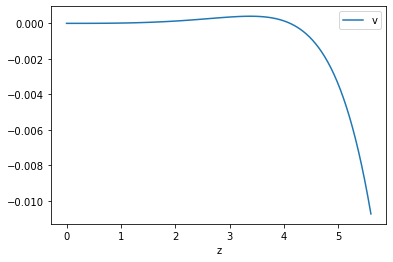

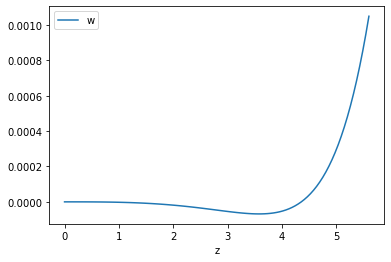

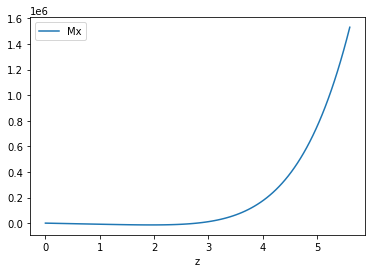

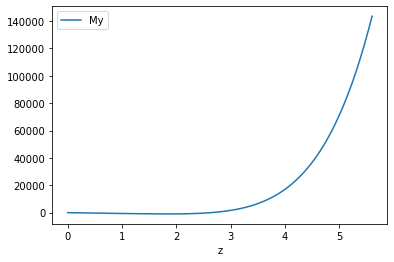

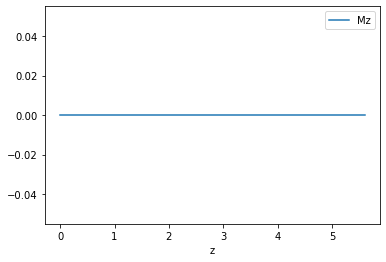

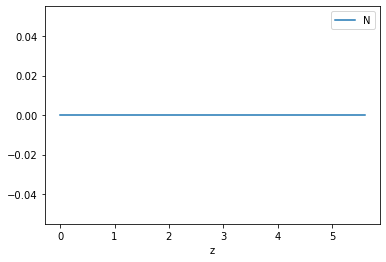

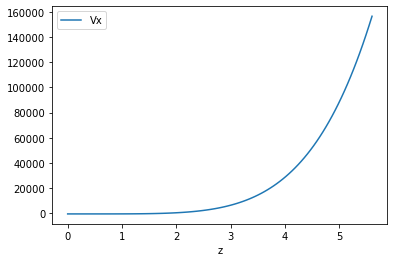

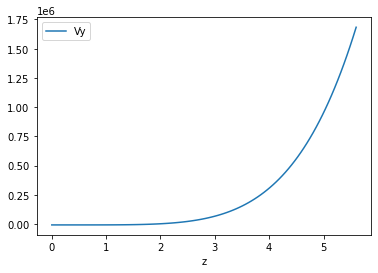

In [9]:
wing.create_nvm(11.2)

In [ ]:
from MathFunctions.Trigonometry import cos, pi

class Material:
    def __init__(self, E, density, o_yield, Paris=(None, None), **others):
        self.E, self.rho, self.oy = E, density, o_yield
        self.C, self.m = Paris
        self.props = others
        
    @staticmethod
    def betaCenter(aow, center=True): 
        return (1/cos(pi * aow)) ** 0.5 if center else 1.1215 # pg 131

    @staticmethod
    def StressConcentration(beta, a, o):
        return beta * o * (pi * a) ** 0.5

    

In [47]:
import numpy as np

materials = pd.read_html('https://mechanicalc.com/reference/material-properties-tables')
matdfs = {"Carbon Steel": materials[1], "Alloy Steel": materials[2], "Stainless Steel": materials[3], "Cast Iron": materials[4],
         "Aluminum Alloys": materials[5], "Nickel Alloys": materials[6], "Copper Alloys": materials[7], "Titanium Alloys": materials[8]}
for m in matdfs:
    matdfs[m]['Class'] = m
    matdfs[m] = matdfs[m].iloc[:-1]
df = pd.concat(matdfs.values())
description = {}
for num in ('YieldStrength [ksi]', 'UltimateStrength [ksi]', 'Elongation%', 'ElasticModulus [psi]', 'Density[lb/in3]', "Poisson'sRatio"):
    tit = ''.join([letter for letter in num if letter not in ['[', ']', '/', '3', ' ', '%', "'", "'"] and letter.upper() == letter])
    description[tit] = num
    df[tit] = pd.to_numeric(df[num], errors='coerce')
    df.drop(columns=[num], inplace=True)

df = df.replace('---', np.nan)
df.to_csv('materials.csv')
